# GODMAX ← cloelib cosmology: validation

Goal: GODMAX takes background and P(k) from cloelib (default Mpc units) through an adapter
that converts to GODMAX's h-units (`k·h`, `P·h³`, `χ·h`, `H/h`), so cloelib probes (BAO, WL, …)
and GODMAX probes (yy, gy, ky, …) share the same cosmology up to where the models diverge.

Sections:
1. **Baseline**: save GODMAX's current tables, P(k, z) and C_ell *before* any code change.
2. **Backend comparison**: GODMAX with `'cloelib'` (cloelib's `jax_cosmology`) vs `'jax_cosmo'`:
   halo-model P(k, z) and C_ell for gg, yy, shear κκ and CMB lensing κκ.
3. **cloelib vs GODMAX**: both on `jax_cosmology`, each with its own models (matter P(k), galaxy bias),
   same n(z): P(k) and C_ell for shear κκ, gg and CMB lensing κκ.

All files (baseline, figures, summary table) are written to `CLOE/outputs`.

Run with the `cloelike_test` kernel.

## 1. Baseline

### Cosmology tables

Builds `base_class` (background + linear P(k)) and the halofit table with exactly the calls
`get_Pkz.__init__` uses, for a few cosmologies. Saved to `CLOE/outputs/baseline_jaxcosmo.npz`
together with the GODMAX commit, so later sections compare against a fixed reference.

Units (GODMAX): `k` in h/Mpc, `P` in (Mpc/h)³, `χ`, `D_A` in Mpc/h, `dχ/dz` in Mpc/h.

In [1]:
import copy
import json
import subprocess
import sys
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from functools import partial

# The CLOE folder holds the cloelib, cloelike and GODMAX checkouts; everything this
# notebook writes goes to CLOE/outputs. Put CLOE/GODMAX/src and CLOE/cloelib first on the path so
# these checkouts are imported, not whichever godmax / cloelib the kernel has installed.
CLOE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if all((p / d).is_dir() for d in ("cloelib", "cloelike", "GODMAX")))
GODMAX_DIR = CLOE_DIR / "GODMAX"
sys.path.insert(0, str(GODMAX_DIR / "src"))
sys.path.insert(0, str(CLOE_DIR / "cloelib"))

import godmax
from godmax.base_class import base_class
from godmax.helpers.jax_cosmo_power import halofit_parameters, nonlinear_matter_power

assert Path(godmax.__file__).resolve().is_relative_to(GODMAX_DIR), (
    f"godmax loaded from {godmax.__file__}, not {GODMAX_DIR}; restart the kernel and rerun")

# The 'cloelib' backend uses cloelib's jax_cosmology (JAXBackground, JAX(Non)LinearPerturbations).
import cloelib.cosmology.jax_cosmology as cloelib_jax_cosmology
assert Path(cloelib_jax_cosmology.__file__).resolve().is_relative_to(CLOE_DIR / "cloelib"), (
    f"cloelib loaded from {cloelib_jax_cosmology.__file__}, not {CLOE_DIR / 'cloelib'}; restart the kernel and rerun")

PARAMS_YAML = CLOE_DIR / "cloelike" / "notebooks" / "godmax_params.yaml"
OUT_DIR = CLOE_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)
BASELINE = OUT_DIR / "baseline_jaxcosmo.npz"

# Check which checkout is loaded before trusting any result (see BUGS.md B12).
print("godmax:", godmax.__file__)
print("cloelib jax_cosmology:", cloelib_jax_cosmology.__file__)
commit = subprocess.run(["git", "-C", str(GODMAX_DIR), "rev-parse", "--short", "HEAD"],
                        capture_output=True, text=True).stdout.strip()
dirty = subprocess.run(["git", "-C", str(GODMAX_DIR), "status", "--porcelain", "src"],
                       capture_output=True, text=True).stdout.strip() != ""
print("commit:", commit, "(src has uncommitted changes)" if dirty else "(src clean)")
print("x64:", jax.config.jax_enable_x64)

/home/vtinnane/micromamba/envs/cloelike/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


godmax: /home/vtinnane/Documents/Codes/develop/CLOE/GODMAX/src/godmax/__init__.py
cloelib jax_cosmology: /home/vtinnane/Documents/Codes/develop/CLOE/cloelib/cloelib/cosmology/jax_cosmology.py
commit: 403b6dd (src has uncommitted changes)
x64: True


In [2]:
with open(PARAMS_YAML) as f:
    PARAMS = yaml.safe_load(f)

# Cosmologies to baseline. low_h checks the h-dependence of the unit conversion.
COSMOS = {
    "fiducial": dict(flat=True, H0=67.2, Om0=0.31, Ob0=0.049, sigma8=0.81, ns=0.95, w0=-1.0),
    "low_h":    dict(flat=True, H0=50.0, Om0=0.31, Ob0=0.049, sigma8=0.81, ns=0.95, w0=-1.0),
    "high_Om":  dict(flat=True, H0=67.2, Om0=0.36, Ob0=0.049, sigma8=0.81, ns=0.95, w0=-1.0),
}


def godmax_tables(cosmo, backend="jax_cosmo"):
    p = copy.deepcopy(PARAMS)
    p["sim_params"]["cosmo"] = dict(cosmo)
    p["sim_params"]["init_power"] = True
    p["analysis"]["symbolic_pk"] = False
    p["analysis"]["cosmology_backend"] = backend
    bc = base_class(p["sim_params"], p["halo_params"], p["analysis"], p["other_params"])

    # Same halofit calls as get_Pkz.__init__ (non-symbolic branch) for each backend.
    if backend == "cloelib":
        phfit = bc.cosmo_cloelib.nonlinear_power(bc.kPk_array, bc.z_array)
    else:
        hfit_params = jax.vmap(partial(halofit_parameters, num_points=bc.num_points_halofit),
                               (None, 0))(bc.cosmo_jax, bc.scale_fac_a_array).T
        phfit = jax.vmap(nonlinear_matter_power, (None, None, 0, None, None, None))(
            bc.cosmo_jax, bc.kPk_array, bc.scale_fac_a_array, bc.plin_kz_mat, hfit_params,
            bc.scale_fac_a_array).T

    return dict(
        z=np.asarray(bc.z_array),
        k=np.asarray(bc.kPk_array),
        chi=np.asarray(bc.chi_array),
        DA=np.asarray(bc.DA_array),
        dchi_dz=np.asarray(bc.dchi_dz_array),
        growth=np.asarray(bc.growth_array),
        plin=np.asarray(bc.plin_kz_mat),     # (nk, nz)
        phfit=np.asarray(phfit),             # (nk, nz)
        chi_CMB=np.asarray(bc.chi_CMB),
        num_points_halofit=np.asarray(bc.num_points_halofit),
    )


tables = {name: godmax_tables(c) for name, c in COSMOS.items()}
for name, t in tables.items():
    print(f"{name:9s} plin {t['plin'].shape}  phfit {t['phfit'].shape}  "
          f"finite: {np.isfinite(t['plin']).all() and np.isfinite(t['phfit']).all()}")

fiducial  plin (256, 48)  phfit (256, 48)  finite: True
low_h     plin (256, 48)  phfit (256, 48)  finite: True
high_Om   plin (256, 48)  phfit (256, 48)  finite: True


### Full pipeline: P(k, z) and C_ell

One `get_Cl` run per lensing kernel at the fiducial cosmology. `is_cmb_lensing` switches the
`kappa` kernel between CMB lensing (`True`) and the shear n(z) (`False`), so `Cl_kappa_*` are
kk / gk / ky for the first run and shear spectra for the second. Each run takes ~10–30 s.

In [3]:
from godmax.get_Cls import get_Cl

PK_KEYS = ["phfit_kz_mat", "Pmm_tot_mat", "Pym_tot_mat", "Pyy_tot_kz_mat",
           "Pgm_tot_mat", "Pge_tot_mat", "Pgy_tot_mat", "Pgg_tot_mat"]
CL_KEYS = ["ell_array", "Cl_kappa_kappa_tot_mat", "Cl_gal_gal_tot_mat", "Cl_gal_kappa_tot_mat",
           "Cl_kappa_y_tot_mat", "Cl_gal_y_tot_mat", "Cl_y_y_signal_mat"]


def godmax_pipeline(cosmo, is_cmb_lensing, backend="jax_cosmo"):
    p = copy.deepcopy(PARAMS)
    p["sim_params"]["cosmo"] = dict(cosmo)
    p["analysis"]["is_cmb_lensing"] = is_cmb_lensing
    p["analysis"]["cosmology_backend"] = backend
    cl = get_Cl(p["sim_params"], p["halo_params"], p["analysis"], p["other_params"])
    # Keys absent for this config (e.g. model_galaxies=False) are skipped.
    return {key: np.asarray(getattr(cl, key)) for key in PK_KEYS + CL_KEYS if hasattr(cl, key)}


pipeline = {
    "cmblens": godmax_pipeline(COSMOS["fiducial"], is_cmb_lensing=True),
    "shear": godmax_pipeline(COSMOS["fiducial"], is_cmb_lensing=False),
}
for name, out in pipeline.items():
    print(f"{name:8s}", {key: val.shape for key, val in out.items()})

/home/vtinnane/Documents/Codes/develop/CLOE/GODMAX/src/godmax/get_radial_profiles.py:96: RuntimeWarning: FFTLog grid under-covers the halo profiles: rmax (r_array[-1]) = 8 Mpc < max profile extent 45.3 Mpc (rt_max = 30.2, r_ej_max = 7.55). Massive/extended haloes are truncated on the grid, so _profile_grid_mass < Mtot and u(k) is distorted for them. Increase halo_params['rmax'] to >~ 45.3 Mpc.
  return func(self, *args, **kwargs)


/home/vtinnane/Documents/Codes/develop/CLOE/GODMAX/src/godmax/get_radial_profiles.py:96: RuntimeWarning: FFTLog grid under-covers the halo profiles: rmax (r_array[-1]) = 8 Mpc < max profile extent 45.3 Mpc (rt_max = 30.2, r_ej_max = 7.55). Massive/extended haloes are truncated on the grid, so _profile_grid_mass < Mtot and u(k) is distorted for them. Increase halo_params['rmax'] to >~ 45.3 Mpc.
  return func(self, *args, **kwargs)


cmblens  {'phfit_kz_mat': (256, 48), 'Pmm_tot_mat': (256, 48), 'Pym_tot_mat': (256, 48), 'Pyy_tot_kz_mat': (256, 48), 'Pgm_tot_mat': (256, 48), 'Pge_tot_mat': (1, 256), 'Pgy_tot_mat': (256, 48), 'Pgg_tot_mat': (256, 48), 'ell_array': (48,), 'Cl_kappa_kappa_tot_mat': (48, 1, 1), 'Cl_gal_gal_tot_mat': (48, 1, 1), 'Cl_gal_kappa_tot_mat': (48, 1, 1), 'Cl_kappa_y_tot_mat': (48, 1), 'Cl_gal_y_tot_mat': (48, 1), 'Cl_y_y_signal_mat': (48,)}
shear    {'phfit_kz_mat': (256, 48), 'Pmm_tot_mat': (256, 48), 'Pym_tot_mat': (256, 48), 'Pyy_tot_kz_mat': (256, 48), 'Pgm_tot_mat': (256, 48), 'Pge_tot_mat': (1, 256), 'Pgy_tot_mat': (256, 48), 'Pgg_tot_mat': (256, 48), 'ell_array': (48,), 'Cl_kappa_kappa_tot_mat': (48, 1, 1), 'Cl_gal_gal_tot_mat': (48, 1, 1), 'Cl_gal_kappa_tot_mat': (48, 1, 1), 'Cl_kappa_y_tot_mat': (48, 1), 'Cl_gal_y_tot_mat': (48, 1), 'Cl_y_y_signal_mat': (48,)}


### Save

In [4]:
save = {"meta": json.dumps({"commit": commit, "src_dirty": dirty, "godmax_file": godmax.__file__,
                            "cosmos": COSMOS, "params_yaml": str(PARAMS_YAML)})}
for name, t in tables.items():
    for key, val in t.items():
        save[f"tables/{name}/{key}"] = val
for name, out in pipeline.items():
    for key, val in out.items():
        save[f"pipeline/{name}/{key}"] = val

if BASELINE.exists():
    print(f"{BASELINE.name} exists; not overwritten. Delete it to regenerate.")
else:
    np.savez(BASELINE, **save)
    print("saved", BASELINE)

baseline_jaxcosmo.npz exists; not overwritten. Delete it to regenerate.


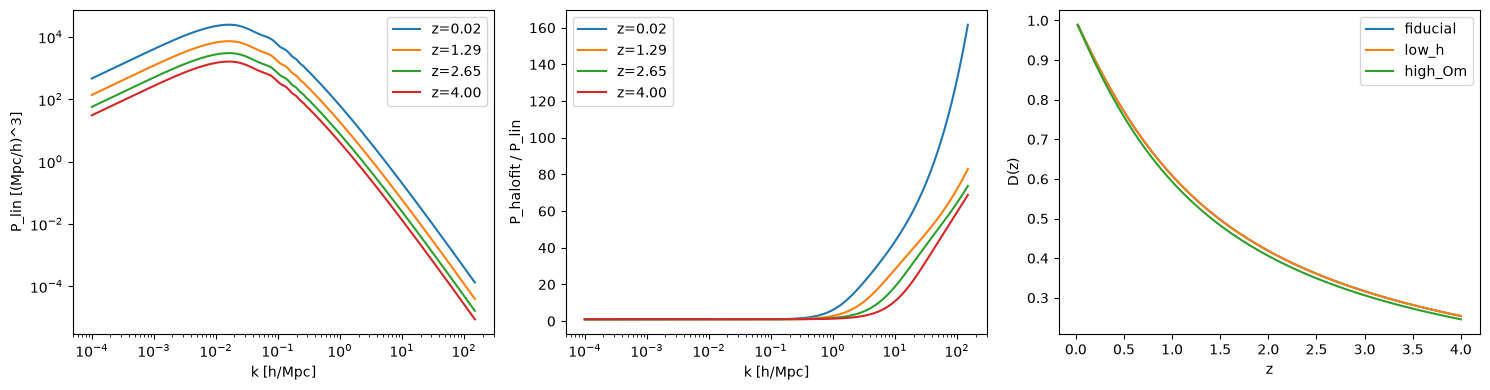

In [5]:
# Sanity plots: P_lin and P_halofit at a few z, and the growth factor.
t = tables["fiducial"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for iz in np.linspace(0, len(t["z"]) - 1, 4).astype(int):
    axes[0].loglog(t["k"], t["plin"][:, iz], label=f"z={t['z'][iz]:.2f}")
    axes[1].semilogx(t["k"], t["phfit"][:, iz] / t["plin"][:, iz], label=f"z={t['z'][iz]:.2f}")
axes[0].set(xlabel="k [h/Mpc]", ylabel="P_lin [(Mpc/h)^3]")
axes[1].set(xlabel="k [h/Mpc]", ylabel="P_halofit / P_lin")
for name, tt in tables.items():
    axes[2].plot(tt["z"], tt["growth"], label=name)
axes[2].set(xlabel="z", ylabel="D(z)")
for ax in axes:
    ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "sanity_pk_growth.png", dpi=150)


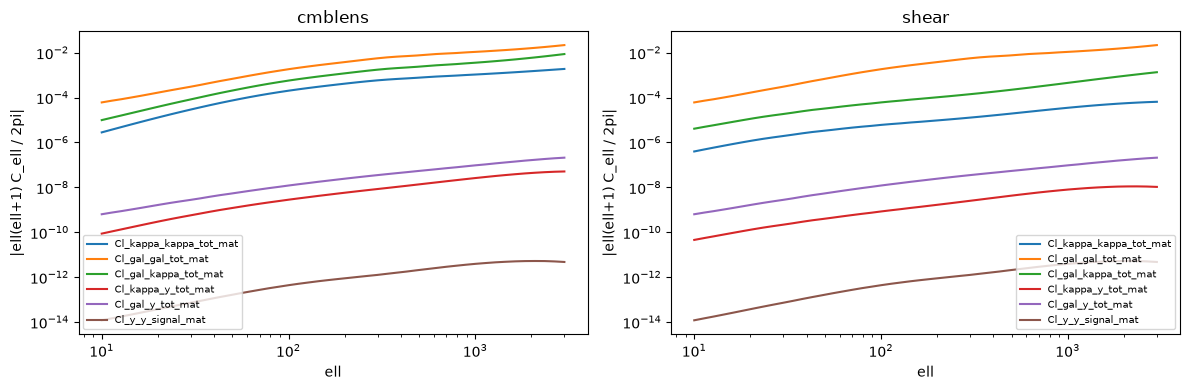

In [6]:
# Sanity plot: C_ell from both runs, first bin (pair) of each spectrum.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, out) in zip(axes, pipeline.items()):
    ell = out["ell_array"]
    for key in CL_KEYS[1:]:
        if key in out:
            cl = out[key].reshape(len(ell), -1)[:, 0]  # ell is axis 0: (nell,), (nell, nb) or (nell, nb, nb)
            ax.loglog(ell, np.abs(ell * (ell + 1) * cl / (2 * np.pi)), label=key)
    ax.set(xlabel="ell", ylabel="|ell(ell+1) C_ell / 2pi|", title=name)
    ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(OUT_DIR / "sanity_cl.png", dpi=150)


## 2. Backend comparison: `cloelib` vs `jax_cosmo`

Both sides are the full GODMAX pipeline (`get_Cl`) at the fiducial cosmology with identical settings;
only `analysis['cosmology_backend']` differs. With `'cloelib'`, GODMAX takes its background and
linear/halofit P(k) from cloelib's `jax_cosmology` (converted to h-units); the halo model, profiles,
kernels and Limber integrals are the same code. So this compares GODMAX's outputs under the two
cosmology codes.

| Probe | P(k, z) | C_ell (run) |
|---|---|---|
| gg | `Pgg_tot_mat` | `Cl_gal_gal_tot_mat` (either run) |
| yy | `Pyy_tot_kz_mat` | `Cl_y_y_signal_mat` (either run) |
| shear κκ | `Pmm_tot_mat` | `Cl_kappa_kappa_tot_mat` (`is_cmb_lensing=False`) |
| CMB lensing κκ | `Pmm_tot_mat` | `Cl_kappa_kappa_tot_mat` (`is_cmb_lensing=True`) |

Every panel shows `cloelib / jax_cosmo - 1`; the grey band is `±TOL`.

### Matching toggles

The two codes use the same physics but compute three things numerically differently. Each toggle
replaces cloelib's version with GODMAX's **only while the cloelib runs execute** (restored afterwards;
no library code changes), so that difference cancels in the ratios. All `False` compares the backends
as they are; switching them on one at a time shows how much each difference contributes.

| Toggle | GODMAX (`jax_cosmo` path) | cloelib `jax_cosmology` | Affects |
|---|---|---|---|
| `MATCH_SIGMA8` | σ²(8) for the P_lin normalisation: integrand in ln k, limits `log10(1e-4)`, `log10(500)` (k ≈ 0.018–14.9 h/Mpc), Simpson N = 64 | ln k ∈ [ln 1e-4, ln 100] h/Mpc, N = 256 | every P(k) and C_ell |
| `MATCH_CHI` | χ(z), D_A(z) from jax_cosmo's tabulated distance, interpolated | `quadgk` integral at each z (agrees with direct quadrature; jax_cosmo is ~0.5% high at z ≈ 0.02) | C_ell (Limber k = (ℓ+½)/χ, 1/χ² weight, kernels) |
| `MATCH_HALOFIT` | k_nl, n_eff, C in h-units: R ∈ [1e-4, 10] Mpc/h on `num_points_halofit` nodes, σ(R) integral k ∈ [1e-4, 1e4] h/Mpc, n_eff/C integral k ∈ [1e-4, 5e2] h/Mpc, Simpson N = `num_points_halofit` | the same limits read in **1/Mpc** (R in Mpc, k up to 1e4 1/Mpc for both integrals), 256 nodes | halofit, hence P_mm and κκ |

The halofit formula itself (Takahashi 2012 coefficients, Ω_m(a), w) is identical in both codes.


In [11]:
TOL = 1e-3  # target max |cloelib / jax_cosmo - 1|

# Matching toggles (see the table above). True: cloelib uses GODMAX's numerics for that quantity.
MATCH_SIGMA8 = True
MATCH_CHI = True
MATCH_HALOFIT = True

import jax_cosmo
import jax_cosmo.transfer as tklib
from jax_cosmo.background import angular_diameter_distance as jc_angular_diameter_distance
from jax_cosmo.background import radial_comoving_distance as jc_radial_comoving_distance
from jax_cosmo.scipy.integrate import simps as jc_simps
from jax_cosmo.scipy.interpolate import interp as jc_interp
from cloelib.cosmology.jax_cosmology import JAXLinearPerturbations, JAXNonLinearPerturbations
from cloelib.cosmology.jax_cosmology import simps as cloelib_simps
from godmax.helpers.cloelib_cosmology import CloelibCosmology
from godmax.helpers.jax_cosmo_power import sigmasqr as godmax_sigmasqr

N_HALOFIT = int(PARAMS["analysis"].get("num_points_halofit", 512))  # GODMAX's halofit grid


def sigma8sqr_godmax(self, kmin=1e-4, kmax=500.0):
    # GODMAX's helpers/jax_cosmo_power.sigmasqr: integrand in ln k, limits log10(kmin), log10(kmax), N = 64.
    R = 8.0

    def int_sigma(logk):
        k = jnp.exp(logk)
        x = k * R
        w = 3.0 * (jnp.sin(x) - x * jnp.cos(x)) / (x * x * x)
        pk = self.transfer_Eisenstein_Hu(k) ** 2 * self.primordial_matter_power(k)
        return k * (k * w) ** 2 * pk

    return cloelib_simps(int_sigma, jnp.log10(kmin), jnp.log10(kmax), N=64) / (2.0 * jnp.pi**2)


def as_jax_cosmo(cosmo_cl):
    # jax_cosmo Cosmology with the parameters of a CloelibCosmology (as base_class builds cosmo_jax).
    bg = cosmo_cl.background
    return jax_cosmo.Cosmology(Omega_c=bg.Omega_cdm0, Omega_b=bg.Omega_b0, h=bg.h,
                               sigma8=bg.interface_args["JAXparams"]["sigma_8"], n_s=bg.ns,
                               Omega_k=0.0, w0=bg.w0, wa=0.0)


def comoving_distance_godmax(self, z):
    return jc_radial_comoving_distance(as_jax_cosmo(self), 1.0 / (1.0 + jnp.atleast_1d(z)))


def angular_diameter_distance_godmax(self, z):
    return jc_angular_diameter_distance(as_jax_cosmo(self), 1.0 / (1.0 + jnp.atleast_1d(z)))


def halofit_parameters_godmax(self, zs):
    # GODMAX's helpers/jax_cosmo_power.halofit_parameters, on cloelib's linear P(k):
    # h-units, N_HALOFIT nodes/steps, n_eff and C integrated to k = 5e2 h/Mpc.
    lin = self.linearperturbations
    logr = jnp.linspace(jnp.log(1e-4), jnp.log(1e1), N_HALOFIT)  # R in Mpc/h

    def pk0(k):  # z = 0 linear P(k) [(Mpc/h)^3] at k [h/Mpc]
        return lin.matter_power_spectrum(0.0, k, hubble_units=True, k_hunit=True)

    @jax.vmap
    def R_nl(z):
        g = lin.growth_factor(jnp.atleast_1d(z))

        def int_sigma(logk):
            k = jnp.exp(logk)
            y = jnp.outer(k, jnp.exp(logr))
            return jnp.expand_dims(pk0(k) * k**3, axis=1) * jnp.exp(-(y**2)) / (2.0 * jnp.pi**2) * g**2

        sigma = jc_simps(int_sigma, jnp.log(1e-4), jnp.log(1e4), N_HALOFIT)
        return jnp.exp(jc_interp(jnp.atleast_1d(1.0), sigma, logr)).clip(1e-6)

    k_nl = 1.0 / R_nl(jnp.atleast_1d(zs)).squeeze()  # h/Mpc
    g = jnp.expand_dims(lin.growth_factor(jnp.atleast_1d(zs)), 0)

    def integrand(logk):
        k = jnp.exp(logk)
        y = jnp.outer(k, 1.0 / k_nl)
        res = jnp.expand_dims(pk0(k) * k**3, axis=1) * jnp.exp(-(y**2)) * g**2 / (2.0 * jnp.pi**2)
        return jnp.stack([2 * res * y**2, 4 * res * (y**2 - y**4)], axis=1)

    res = jc_simps(integrand, jnp.log(1e-4), jnp.log(5e2), N_HALOFIT)
    n_eff = res[0] - 3.0
    C = res[0] ** 2 + res[1]
    return k_nl * self.background.h, n_eff, C  # cloelib's halofit works in 1/Mpc


PATCHES = [
    (MATCH_SIGMA8, JAXLinearPerturbations, "sigma8sqr", sigma8sqr_godmax),
    (MATCH_CHI, CloelibCosmology, "comoving_distance", comoving_distance_godmax),
    (MATCH_CHI, CloelibCosmology, "angular_diameter_distance", angular_diameter_distance_godmax),
    (MATCH_HALOFIT, JAXNonLinearPerturbations, "_halofit_parameters", halofit_parameters_godmax),
]
originals = [(cls, name, cls.__dict__[name]) for _, cls, name, _ in PATCHES]
print(f"MATCH_SIGMA8 = {MATCH_SIGMA8}, MATCH_CHI = {MATCH_CHI}, MATCH_HALOFIT = {MATCH_HALOFIT}")
try:
    for on, cls, name, func in PATCHES:
        if on:
            setattr(cls, name, func)

    # Spot checks at the fiducial cosmology: sigma^2(8) and chi(z = 0.02) seen by each backend.
    p = copy.deepcopy(PARAMS)
    p["sim_params"]["cosmo"] = dict(COSMOS["fiducial"])
    p["sim_params"]["init_power"] = False
    bc = base_class(p["sim_params"], p["halo_params"], p["analysis"], p["other_params"])
    cosmo_cl = CloelibCosmology.from_godmax_params(COSMOS["fiducial"])
    s2_jc = float(godmax_sigmasqr(bc.cosmo_jax, 8.0, tklib.Eisenstein_Hu))
    s2_cl = float(cosmo_cl.linear.sigma8sqr())
    chi_jc = float(jc_radial_comoving_distance(bc.cosmo_jax, jnp.atleast_1d(1 / 1.02))[0])
    chi_cl = float(cosmo_cl.comoving_distance(0.02)[0])
    print(f"sigma^2(8):  cloelib / jax_cosmo - 1 = {s2_cl / s2_jc - 1:+.2e}")
    print(f"chi(0.02):   cloelib / jax_cosmo - 1 = {chi_cl / chi_jc - 1:+.2e}")

    pipeline_cl = {
        "cmblens": godmax_pipeline(COSMOS["fiducial"], is_cmb_lensing=True, backend="cloelib"),
        "shear": godmax_pipeline(COSMOS["fiducial"], is_cmb_lensing=False, backend="cloelib"),
    }
finally:
    for cls, name, func in originals:
        setattr(cls, name, func)

summary = {}  # quantity -> max |rel diff|
k_arr, z_arr = tables["fiducial"]["k"], tables["fiducial"]["z"]
Z_IDX = np.linspace(0, len(z_arr) - 1, 4).astype(int)


def rel_diff(new, ref):
    new, ref = np.asarray(new), np.asarray(ref)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(ref != 0, new / ref - 1, np.nan)


def tol_band(ax):
    ax.axhspan(-TOL, TOL, color="0.88", zorder=0)
    ax.axhline(0, color="k", lw=0.6)

MATCH_SIGMA8 = True, MATCH_CHI = True, MATCH_HALOFIT = True
sigma^2(8):  cloelib / jax_cosmo - 1 = +0.00e+00
chi(0.02):   cloelib / jax_cosmo - 1 = +0.00e+00


### 2.1 Halo-model P(k, z)

Each panel shows the ratio as a function of k at 4 of the 48 halo-model redshifts (lowest to highest).

Section 2 runs GODMAX twice per backend: once with `is_cmb_lensing=True` (κ = CMB lensing) and once
with `False` (κ = shear). That switch only changes how P(k, z) is projected into C_ell; P(k, z) itself
is identical in both runs, so it is plotted from the `is_cmb_lensing=True` run.

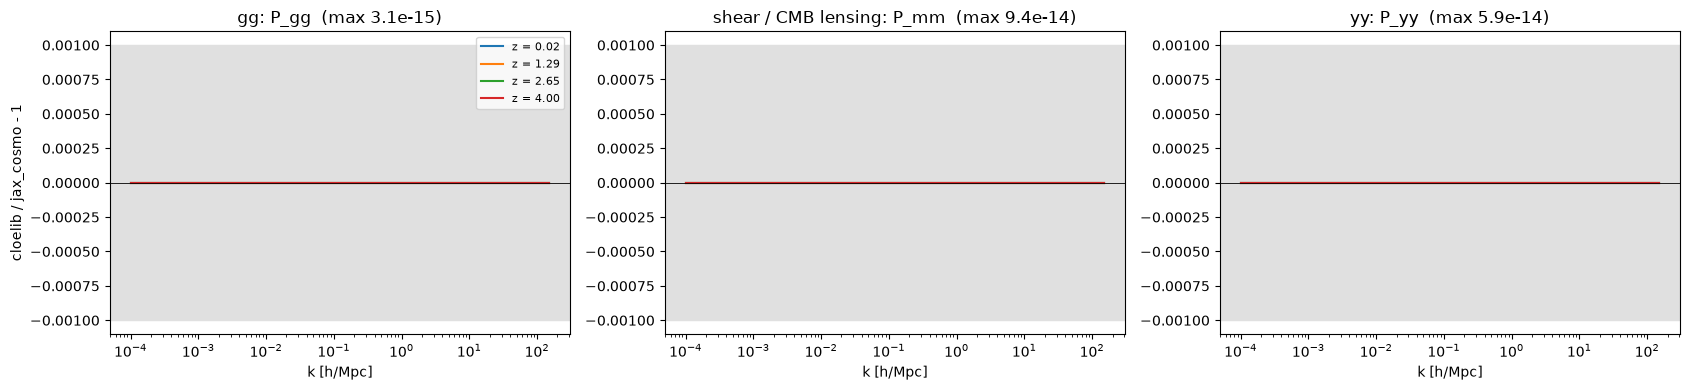

In [12]:
PK_PROBES = [
    ("Pgg_tot_mat", "gg: P_gg"),
    ("Pmm_tot_mat", "shear / CMB lensing: P_mm"),
    ("Pyy_tot_kz_mat", "yy: P_yy"),
]

pj, pc = pipeline["cmblens"], pipeline_cl["cmblens"]
fig, axes = plt.subplots(1, len(PK_PROBES), figsize=(17, 4))
for ax, (key, label) in zip(axes, PK_PROBES):
    r = rel_diff(pc[key], pj[key])
    summary[label] = float(np.nanmax(np.abs(r)))
    for iz in Z_IDX:
        ax.semilogx(k_arr, r[:, iz], label=f"z = {z_arr[iz]:.2f}")
    tol_band(ax)
    ax.set(xlabel="k [h/Mpc]", title=f"{label}  (max {summary[label]:.1e})")
axes[0].set_ylabel("cloelib / jax_cosmo - 1")
axes[0].legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUT_DIR / "compare_pk.png", dpi=150)

### 2.2 Angular power spectra

Each line is one tomographic bin (pair).

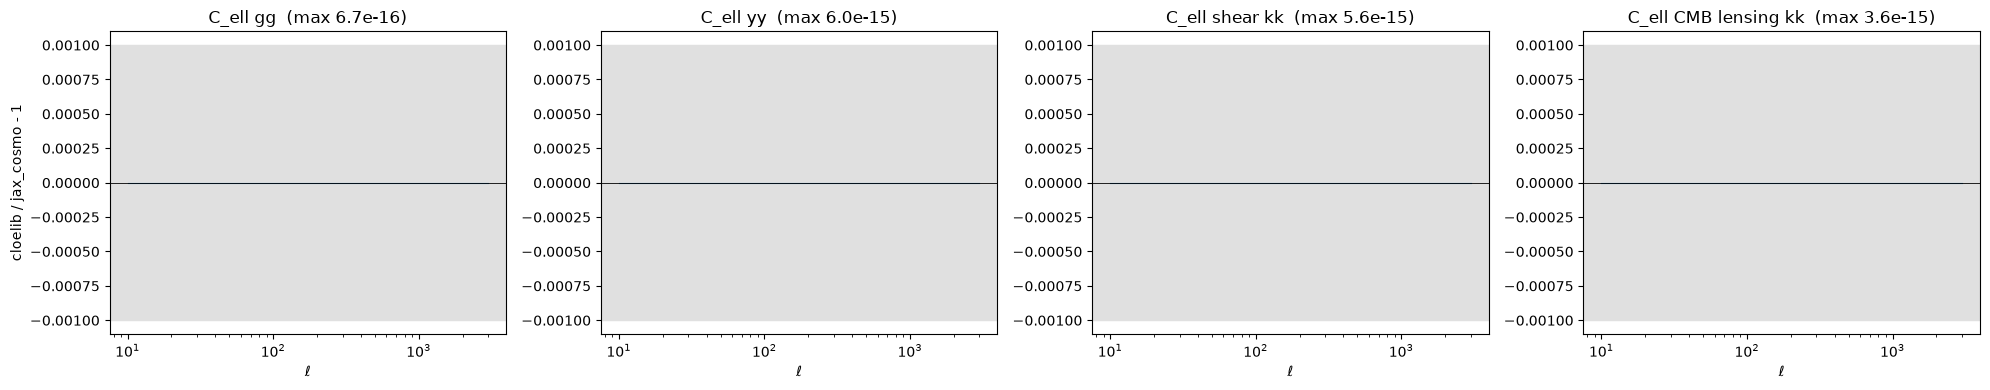

In [13]:
CL_PROBES = [
    ("cmblens", "Cl_gal_gal_tot_mat", "gg"),
    ("cmblens", "Cl_y_y_signal_mat", "yy"),
    ("shear", "Cl_kappa_kappa_tot_mat", "shear kk"),
    ("cmblens", "Cl_kappa_kappa_tot_mat", "CMB lensing kk"),
]

fig, axes = plt.subplots(1, len(CL_PROBES), figsize=(20, 4))
for ax, (run, key, label) in zip(axes, CL_PROBES):
    ell = pipeline[run]["ell_array"]
    r = rel_diff(pipeline_cl[run][key], pipeline[run][key]).reshape(len(ell), -1)  # ell is axis 0
    summary[f"C_ell {label}"] = float(np.nanmax(np.abs(r)))
    ax.semilogx(ell, r, lw=0.8)
    tol_band(ax)
    ax.set(xlabel=r"$\ell$", title=f"C_ell {label}  (max {summary[f'C_ell {label}']:.1e})")
axes[0].set_ylabel("cloelib / jax_cosmo - 1")
plt.tight_layout()
fig.savefig(OUT_DIR / "compare_cls.png", dpi=150)

### 2.3 Summary

Max |cloelib / jax_cosmo - 1| over the full k–z or ℓ–bin grid. Also written to
`CLOE/outputs/backend_comparison_summary.csv`.

In [14]:
import csv

width = max(len(q) for q in summary)
print(f"{'quantity':{width}s} {'max|rel diff|':>13s}  <= TOL ({TOL:g})")
for quantity, m in summary.items():
    print(f"{quantity:{width}s} {m:13.2e}  {'yes' if m <= TOL else 'NO'}")

with open(OUT_DIR / "backend_comparison_summary.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["quantity", "max_abs_rel_diff", "within_tol"])
    writer.writerows([(q, m, m <= TOL) for q, m in summary.items()])

quantity                  max|rel diff|  <= TOL (0.001)
gg: P_gg                       3.11e-15  yes
shear / CMB lensing: P_mm      9.40e-14  yes
yy: P_yy                       5.88e-14  yes
C_ell gg                       6.66e-16  yes
C_ell yy                       6.00e-15  yes
C_ell shear kk                 5.55e-15  yes
C_ell CMB lensing kk           3.55e-15  yes


## 3. cloelib vs GODMAX: shear κκ, gg and CMB lensing κκ

CLOE will run GODMAX on cloelib's `jax_cosmology`, so both codes share the cosmology (section 2).
Here **each code uses its own model** for the three common probes:

| | cloelib (`jax_cosmology`) | GODMAX (defaults) |
|---|---|---|
| Matter P(k) (shear, CMB lensing) | halofit, no baryons | halofit × P_DMB / P_NFW (halo-model baryon correction) |
| Galaxy P(k) (gg) | b² × halofit, one constant bias b | HOD halo model (1-halo + 2-halo) |
| Galaxy bias | b = GODMAX's large-scale HOD bias at z = 0.5 | from the HOD |

**Identical on both sides:** cosmology (fiducial), ℓ values, k values, redshift grid (0.02–4, 81 points), and the n(z):
galaxies Gaussian at z = 0.5 (σ = 0.1), shear sources Gaussian at z = 1.0 (σ = 0.2).
All systematics are off: no intrinsic alignments, m = 0, no photo-z shift, no magnification, no RSD.
Section 2's matching toggles are not needed: both sides use the same cloelib code for σ8, χ and halofit.

`MATCH_Z_GRID` (GODMAX cell): `True` makes GODMAX compute P(k) on the same 81 redshifts as cloelib instead of
its 48 halo-model redshifts, so no z-interpolation of P(k) or χ enters GODMAX's Limber integral.

**Differences to expect that are not the model:**
- cloelib multiplies each shear leg by the spin-2 factor √((ℓ+2)(ℓ+1)ℓ(ℓ−1))/(ℓ+½)²; GODMAX does not
  (≈ −2% on shear κκ at ℓ = 10, negligible above ℓ ≈ 60). Shown as a dashed line in the shear ratio panel.
- CMB lensing source: z* = 1090 in cloelib, z = 1100 in GODMAX (small).
- Numerics: cloelib interpolates P(k) in 2D (Akima) and integrates in z with Simpson; GODMAX interpolates
  in log k then (ln ℓ, z) and uses the trapezoid rule. With `MATCH_Z_GRID = False`, GODMAX also
  interpolates P(k) and χ from its 48 halo-model redshifts (sub-percent for κκ, larger at low z).

GODMAX needs two runs because its κ kernel is either CMB lensing (`is_cmb_lensing=True`) or shear (`False`).

In [18]:
from cloelib.cosmology.jax_cosmology import JAXBackground, JAXNonLinearPerturbations
from cloelib.observables.cmb import CMBLensingTracer
from cloelib.observables.photo import PositionsTracer, ShearTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from godmax.get_Cls import get_Cl

cosmo = COSMOS["fiducial"]
h = cosmo["H0"] / 100

# Redshift grid shared by both codes: GODMAX's C_ell grid (equispaced, no z = 0, as cloelib needs).
z_grid = np.linspace(PARAMS["analysis"]["zmin_for_Cls"], PARAMS["analysis"]["zmax_for_Cls"],
                     PARAMS["analysis"]["nz_for_Cls"])

# One bin each; both codes normalise n(z) themselves.
nz_gal = np.exp(-0.5 * ((z_grid - 0.5) / 0.1) ** 2)    # galaxies (gg)
nz_shear = np.exp(-0.5 * ((z_grid - 1.0) / 0.2) ** 2)  # shear sources

In [24]:
# --- GODMAX: full pipeline with its own models, on cloelib's jax_cosmology

# True: GODMAX computes P(k) (the halo model) on the same 81 redshifts as cloelib, instead of its
# 48 halo-model redshifts, so no z-interpolation of P(k) or chi enters its Limber integral (~70% slower).
MATCH_Z_GRID = True


def run_godmax(is_cmb_lensing):
    p = copy.deepcopy(PARAMS)
    p["sim_params"]["cosmo"] = dict(cosmo)
    p["analysis"]["cosmology_backend"] = "cloelib"
    p["analysis"]["is_cmb_lensing"] = is_cmb_lensing
    p["analysis"]["nz_lens_info_dict"] = {"nbins_lens": 1, "z_array_lens": z_grid.tolist(), "nz0": nz_gal.tolist()}
    p["analysis"]["nz_source_info_dict"] = {"nbins": 1, "z_array_source": z_grid.tolist(), "nz0": nz_shear.tolist()}
    p["other_params"]["A_IA"] = 0.0  # no intrinsic alignments
    if MATCH_Z_GRID:
        p["halo_params"]["z_array"] = z_grid.tolist()
    return get_Cl(p["sim_params"], p["halo_params"], p["analysis"], p["other_params"])


gm_cmb = run_godmax(is_cmb_lensing=True)     # kappa = CMB lensing
gm_shear = run_godmax(is_cmb_lensing=False)  # kappa = shear

ells = np.asarray(gm_cmb.ell_array)
k_h = np.asarray(gm_cmb.kPk_array)       # k [h/Mpc]
z_halo = np.asarray(gm_cmb.z_array)      # redshifts of GODMAX's P(k) tables
print(f"MATCH_Z_GRID = {MATCH_Z_GRID}: GODMAX P(k) on {len(z_halo)} redshifts, cloelib on {len(z_grid)}")
Pmm_godmax = np.asarray(gm_cmb.Pmm_tot_mat)  # matter P(k) with baryons [(Mpc/h)^3], shape (nk, nz)
Pgg_godmax = np.asarray(gm_cmb.Pgg_tot_mat)  # HOD galaxy P(k) [(Mpc/h)^3], shape (nk, nz)

Cl_godmax = {
    "shear kk": np.asarray(gm_shear.Cl_kappa_kappa_tot_mat)[:, 0, 0],
    "gg": np.asarray(gm_cmb.Cl_gal_gal_tot_mat)[:, 0, 0],
    "CMB lensing kk": np.asarray(gm_cmb.Cl_kappa_kappa_tot_mat)[:, 0, 0],
}

# Large-scale HOD galaxy bias (bias at the smallest k) at z = 0.5, used as cloelib's constant b.
b_gal = float(np.interp(0.5, z_halo, np.asarray(gm_cmb.bg_kz_mat)[0]))
print(f"GODMAX large-scale galaxy bias at z = 0.5: b = {b_gal:.3f}")

MATCH_Z_GRID = True: GODMAX P(k) on 81 redshifts, cloelib on 81
GODMAX large-scale galaxy bias at z = 0.5: b = 1.892


In [25]:
# --- cloelib: jax_cosmology + tracers + AngularTwoPoint (Limber), with its own models

class JAXBackgroundScalarChi(JAXBackground):
    # Workaround for a cloelib bug: CMBLensingTracer calls comoving_distance(z_star) with a scalar,
    # but JAXBackground.comoving_distance only accepts arrays ("'float' object is not iterable").
    def comoving_distance(self, zs):
        zs = jnp.asarray(zs)
        chi = super().comoving_distance(jnp.atleast_1d(zs))
        return chi if zs.ndim else chi[0]


# JAXBackground takes As, but its P(k) is normalised by the sigma8 stored in interface_args,
# so GODMAX's sigma8 is written there (exactly what GODMAX's adapter does).
background = JAXBackgroundScalarChi(H0=cosmo["H0"], Omega_b0=cosmo["Ob0"], Omega_cdm0=cosmo["Om0"] - cosmo["Ob0"],
                                    Omega_k0=0.0, As=2.1e-9, ns=cosmo["ns"], mnu=0.0, w0=cosmo["w0"], wa=0.0,
                                    gamma_MG=0.55, N_mnu=0)
background.interface_args["JAXparams"]["sigma_8"] = cosmo["sigma8"]
nlp = JAXNonLinearPerturbations(background)  # halofit
nlp.z = jnp.asarray(z_grid)  # redshifts on which AngularTwoPoint tabulates P(k)

# cloelib works in Mpc, GODMAX in h-units: k [1/Mpc] = k [h/Mpc] * h and P [(Mpc/h)^3] = P [Mpc^3] * h^3.
k_mpc = jnp.asarray(k_h * h)
Pmm_cloelib = np.asarray(nlp.matter_power_spectrum(jnp.asarray(z_halo), k_mpc)).T * h**3  # (nk, nz)
Pgg_cloelib = b_gal**2 * Pmm_cloelib

# Tracers with all systematics off (no IA: ia_model defaults to None).
z_j, nz_gal_j, nz_shear_j = jnp.asarray(z_grid), jnp.asarray(nz_gal)[None, :], jnp.asarray(nz_shear)[None, :]
tracers = {
    "shear kk": ShearTracer(nlp, nz_shear_j, z_j,
                            {"multiplicative_bias_1": 0.0, "dz_shear_1": 0.0, "width_shear_1": 1.0}),
    "gg": PositionsTracer(nlp, nz_gal_j, z_j, galaxy_bias_model="per_bin",
                          nuisance_params={"b1_photo_bin0": b_gal, "dz_pos_1": 0.0, "width_pos_1": 1.0,
                                           "magnification_bias_1": 0.0}),
    "CMB lensing kk": CMBLensingTracer(nlp, z_j),
}
Cl_cloelib = {
    probe: np.asarray(AngularTwoPoint(t, t).get_Cl_tensor(jnp.asarray(ells), 0, k_mpc))[:, 0, 0]
    for probe, t in tracers.items()
}

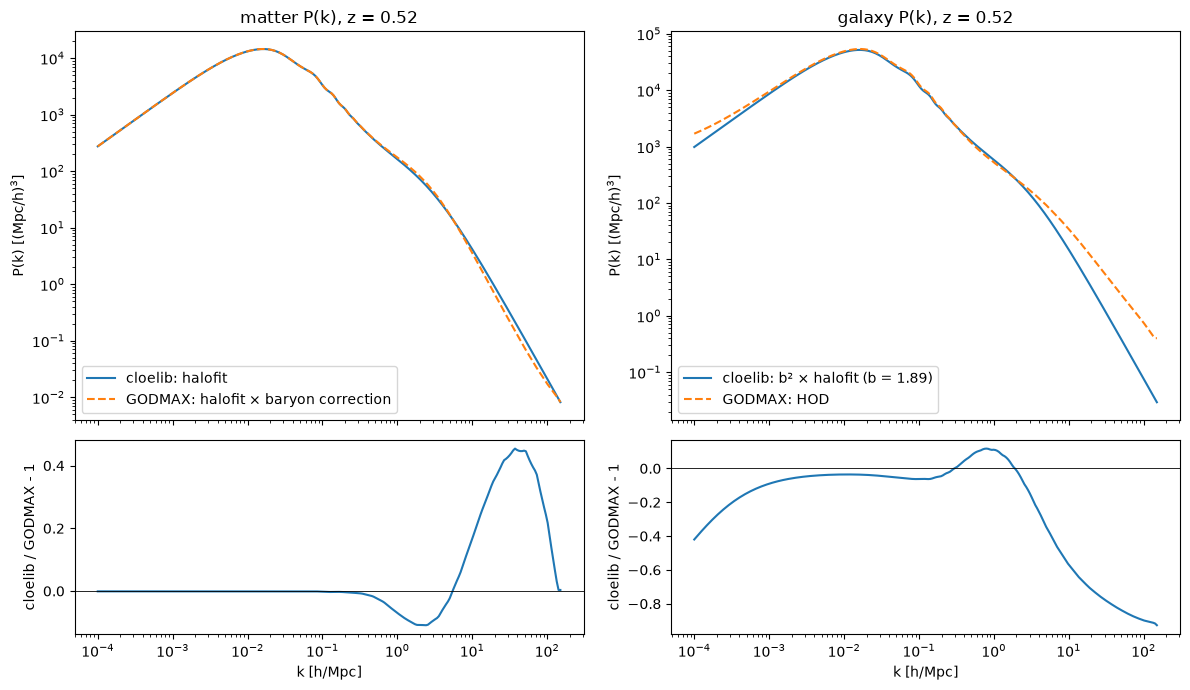

In [26]:
# P(k) at the GODMAX redshift closest to z = 0.5 (the galaxy n(z) peak).
iz = int(np.argmin(np.abs(z_halo - 0.5)))
pk_panels = [
    # title, cloelib, GODMAX, cloelib label, GODMAX label
    ("matter P(k)", Pmm_cloelib[:, iz], Pmm_godmax[:, iz], "cloelib: halofit", "GODMAX: halofit × baryon correction"),
    ("galaxy P(k)", Pgg_cloelib[:, iz], Pgg_godmax[:, iz], f"cloelib: b² × halofit (b = {b_gal:.2f})", "GODMAX: HOD"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for col, (title, P_cloelib, P_godmax, label_cloelib, label_godmax) in enumerate(pk_panels):
    axes[0, col].loglog(k_h, P_cloelib, label=label_cloelib)
    axes[0, col].loglog(k_h, P_godmax, "--", label=label_godmax)
    axes[0, col].set(title=f"{title}, z = {z_halo[iz]:.2f}", ylabel=r"P(k) [(Mpc/h)$^3$]")
    axes[0, col].legend()
    axes[1, col].semilogx(k_h, P_cloelib / P_godmax - 1)
    axes[1, col].axhline(0, color="k", lw=0.6)
    axes[1, col].set(xlabel="k [h/Mpc]", ylabel="cloelib / GODMAX - 1")
plt.tight_layout()
fig.savefig(OUT_DIR / "compare_cloelib_godmax_pk.png", dpi=150)

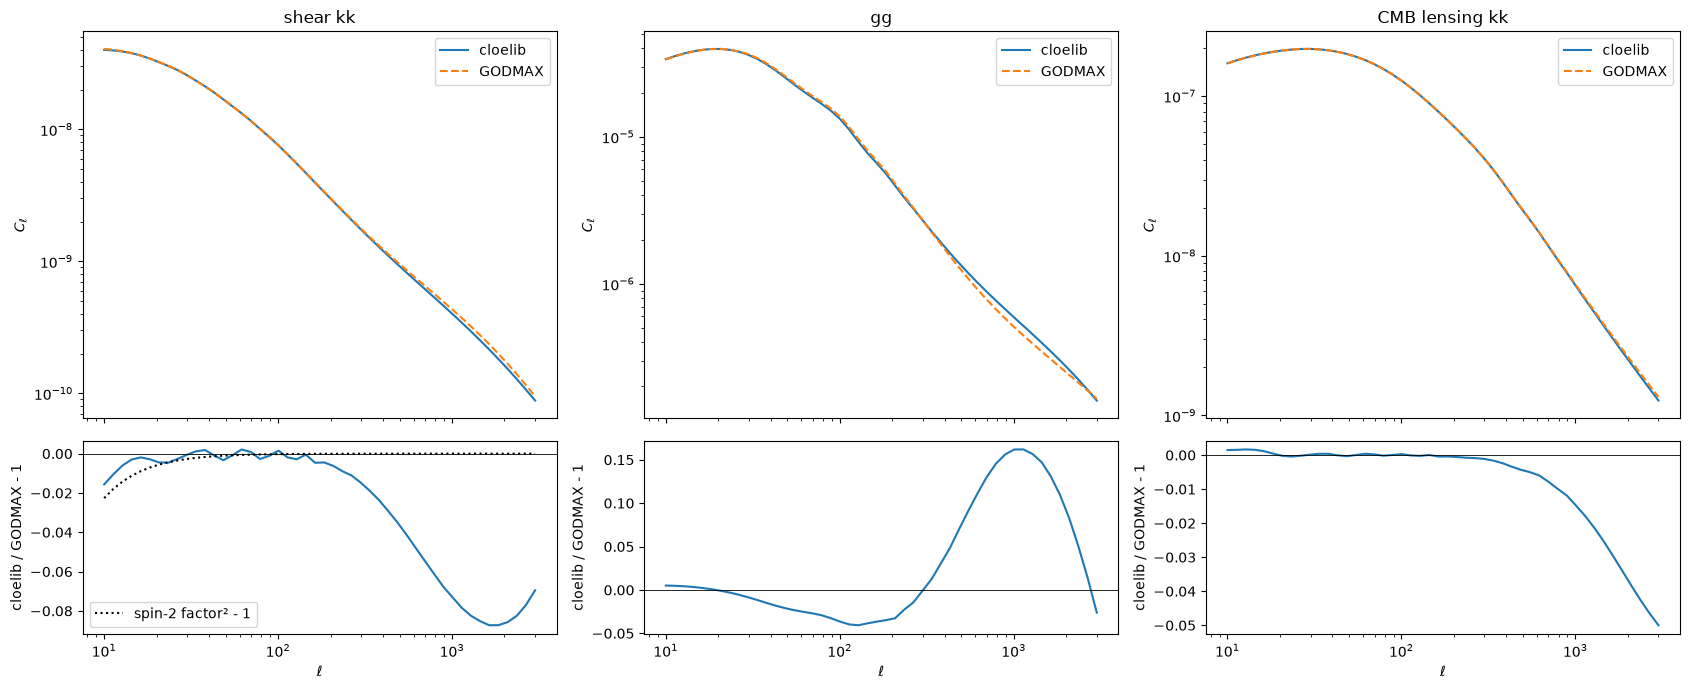

In [27]:
# C_ell for the three probes; bottom row: cloelib / GODMAX - 1.
# cloelib's spin-2 factor on both shear legs (GODMAX has none), for reference in the shear panel.
spin2_factor = np.sqrt((ells + 2) * (ells + 1) * ells * (ells - 1)) / (ells + 0.5) ** 2

fig, axes = plt.subplots(2, 3, figsize=(17, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for col, probe in enumerate(["shear kk", "gg", "CMB lensing kk"]):
    axes[0, col].loglog(ells, Cl_cloelib[probe], label="cloelib")
    axes[0, col].loglog(ells, Cl_godmax[probe], "--", label="GODMAX")
    axes[0, col].set(title=probe, ylabel=r"$C_\ell$")
    axes[0, col].legend()
    axes[1, col].semilogx(ells, Cl_cloelib[probe] / Cl_godmax[probe] - 1)
    axes[1, col].axhline(0, color="k", lw=0.6)
    axes[1, col].set(xlabel=r"$\ell$", ylabel="cloelib / GODMAX - 1")
axes[1, 0].semilogx(ells, spin2_factor**2 - 1, "k:", label="spin-2 factor² - 1")
axes[1, 0].legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "compare_cloelib_godmax_cls.png", dpi=150)